# Poda Alfa-Beta (Alpha-Beta Pruning) — Implementación genérica

Este cuaderno implementa el algoritmo de **Poda Alfa-Beta** para un árbol de juego representado mediante **listas anidadas de Python**.

**Convención de representación:**
- El árbol se describe con listas anidadas. Un nodo interno es una `list`, un nodo hoja es un número.
- Ejemplo: `[ [3,-5,2] , [-5,-7,4] , [-9,6,-8] ]` representa un nodo raíz (MAX) con 3 hijos (nodos MIN), cada uno con 3 hojas.
- Los niveles alternan MAX / MIN empezando por MAX en la raíz (▲ = nodo MAX, ▽ = nodo MIN).
- Se admiten árboles de **hasta 5 niveles** y **hasta 50 nodos hoja**, con ramificación arbitraria en cada nodo (no es necesario que el árbol sea balanceado).

**Contenido del cuaderno:**
1. Carga de librerías.
2. **Configuración** del árbol de entrada (lista manual o generación aleatoria).
3. Estructura de datos del árbol (`Node`) y construcción a partir de la lista.
4. Algoritmo de Poda Alfa-Beta.
5. Generador aleatorio de árboles.
6. Visualización: dibuja el árbol, resalta la **secuencia óptima de jugadas** (rojo) y marca las **ramas podadas** (líneas grises punteadas con ✕).
7. Ejecución y resultados.


In [1]:
# 1. Librerías
import math
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.lines as mlines

%matplotlib inline

In [2]:
# 2. CONFIGURACIÓN
# ---------------------------------------------------------------------------
# Aquí se define el árbol de entrada. Puede:
#   (a) escribirse manualmente como lista anidada en TREE, o
#   (b) generarse aleatoriamente activando USE_RANDOM_TREE = True
#
# Reglas de la lista anidada:
#   - Un número      -> nodo hoja
#   - Una lista       -> nodo interno (sus elementos son los hijos)
#   - Máximo 5 niveles de profundidad, máximo 50 hojas en total.
# ---------------------------------------------------------------------------

# Árbol de ejemplo (el de la figura del enunciado): raíz MAX con 3 hijos MIN de 3 hojas c/u
TREE = [ [3, -5, 2], [-5, -7, 4], [-9, 6, -8] ]

# --- Generación aleatoria ---
USE_RANDOM_TREE   = False   # True => ignora TREE y genera un árbol aleatorio con los parámetros de abajo
RANDOM_NUM_LEVELS = 4       # número de niveles del árbol (incluida la raíz y las hojas), entre 2 y 5
RANDOM_NUM_LEAVES = 16      # número total de nodos hoja, entre 1 y 50
RANDOM_MAX_BRANCH = 4       # número máximo de hijos por nodo interno (excepto el nivel de hojas)
RANDOM_VALUE_RANGE = (-10, 10)  # rango de valores aleatorios para las hojas
RANDOM_SEED = None          # entero para reproducibilidad, o None para aleatorio real

# --- Opciones de visualización ---
SHOW_ALPHA_BETA = True      # muestra los valores alfa/beta calculados en cada nodo interno visitado

## 3. Estructura del árbol

`Node` representa un nodo del árbol de juego. `build_tree` convierte recursivamente la lista anidada
(configurada arriba) en un árbol de objetos `Node`, alternando el tipo de nodo (`is_max`) en cada nivel.

In [3]:
# 3. Nodo del árbol y construcción a partir de la lista anidada
class Node:
    '''Nodo de un arbol de juego (MAX u MIN) o una hoja.'''
    __slots__ = ("is_max", "depth", "name", "children", "value", "is_leaf",
                 "visited", "pruned", "chosen", "alpha_at", "beta_at",
                 "chosen_idx", "x", "y")

    def __init__(self, is_max, depth, name):
        self.is_max = is_max        # True = nodo MAX, False = nodo MIN (ignorado si es hoja)
        self.depth = depth          # profundidad (0 = raíz)
        self.name = name            # identificador legible, ej "0.1.2"
        self.children = []          # lista de Node hijos
        self.value = None           # valor de la hoja, o valor minimax calculado
        self.is_leaf = False
        self.visited = False        # True si el algoritmo evaluó este nodo
        self.pruned = False         # True si el nodo fue podado (nunca evaluado)
        self.chosen = False         # True si pertenece a la secuencia óptima de jugadas
        self.alpha_at = None        # alfa con el que se entró al nodo
        self.beta_at = None         # beta con el que se entró al nodo
        self.chosen_idx = None      # índice del hijo óptimo (para reconstruir el camino)
        self.x = None               # posición para dibujar
        self.y = None


def build_tree(data, depth=0, is_max=True, name="0"):
    '''Construye recursivamente un arbol de Node a partir de una lista anidada.
    - data numerico -> hoja
    - data lista     -> nodo interno; sus elementos son los hijos (alternando MAX/MIN)
    '''
    node = Node(is_max, depth, name)
    if isinstance(data, list):
        if len(data) == 0:
            raise ValueError(f"El nodo '{name}' es una lista vacía: todo nodo interno debe tener al menos un hijo")
        for i, child_data in enumerate(data):
            node.children.append(build_tree(child_data, depth + 1, not is_max, f"{name}.{i}"))
    else:
        node.is_leaf = True
        node.value = data
    return node


def tree_depth(data, d=1):
    if isinstance(data, list):
        return max(tree_depth(c, d + 1) for c in data)
    return d


def count_leaves(data):
    if isinstance(data, list):
        return sum(count_leaves(c) for c in data)
    return 1

## 4. Algoritmo de Poda Alfa-Beta

Recorrido en profundidad (DFS) que mantiene una cota `alpha` (mejor valor garantizado para MAX) y
`beta` (mejor valor garantizado para MIN). Cuando `alpha >= beta` en un nodo, el resto de sus hijos
**no necesitan explorarse** porque no pueden cambiar la decisión del nodo padre: se marcan como podados
(`mark_subtree_pruned`), junto con todo su subárbol.

Al terminar, `mark_optimal_path` recorre desde la raíz siguiendo en cada nodo el hijo que produjo el
valor óptimo (`chosen_idx`), marcando la **secuencia óptima de jugadas**.

In [4]:
# 4. Poda Alfa-Beta

def mark_subtree_pruned(node):
    '''Marca un nodo y todo su subarbol como podado (nunca evaluado).'''
    node.pruned = True
    node.visited = False
    for c in node.children:
        mark_subtree_pruned(c)


def alphabeta(node, alpha=-math.inf, beta=math.inf):
    '''Calcula el valor minimax de node aplicando poda alfa-beta.
    Marca en cada Node: value, visited, pruned, chosen_idx (hijo optimo).'''
    node.visited = True
    node.alpha_at, node.beta_at = alpha, beta

    if node.is_leaf:
        return node.value

    if node.is_max:
        value = -math.inf
        for i, child in enumerate(node.children):
            child_value = alphabeta(child, alpha, beta)
            if child_value > value:
                value = child_value
                node.chosen_idx = i
            alpha = max(alpha, value)
            if alpha >= beta:                      # poda beta
                for j in range(i + 1, len(node.children)):
                    mark_subtree_pruned(node.children[j])
                break
    else:  # nodo MIN
        value = math.inf
        for i, child in enumerate(node.children):
            child_value = alphabeta(child, alpha, beta)
            if child_value < value:
                value = child_value
                node.chosen_idx = i
            beta = min(beta, value)
            if alpha >= beta:                      # poda alfa
                for j in range(i + 1, len(node.children)):
                    mark_subtree_pruned(node.children[j])
                break

    node.value = value
    return value


def mark_optimal_path(node):
    '''Marca la secuencia optima de jugadas siguiendo chosen_idx desde la raiz.'''
    node.chosen = True
    if not node.is_leaf and node.chosen_idx is not None:
        mark_optimal_path(node.children[node.chosen_idx])


def get_optimal_sequence(node):
    '''Devuelve la lista de Node en la secuencia optima, de la raiz a la hoja elegida.'''
    seq = [node]
    while not seq[-1].is_leaf and seq[-1].chosen_idx is not None:
        seq.append(seq[-1].children[seq[-1].chosen_idx])
    return seq


def count_pruned_leaves(node):
    total = 0
    def rec(n):
        nonlocal total
        if n.is_leaf:
            total += n.pruned
        else:
            for c in n.children:
                rec(c)
    rec(node)
    return total

## 5. Generación aleatoria del árbol

`generate_random_tree(num_levels, num_leaves, ...)` construye una lista anidada aleatoria con exactamente
`num_levels` niveles (todas las hojas a la misma profundidad) y exactamente `num_leaves` hojas en total,
repartidas de forma balanceada (con algo de variación aleatoria) entre los nodos internos, respetando
`max_branch` como número máximo de hijos por nodo interno.

In [5]:
# 5. Generador aleatorio de árboles

def random_partition(n, k):
    '''Reparte el entero n en k partes positivas, de forma balanceada con variacion aleatoria.'''
    if k == 1:
        return [n]
    base, rem = divmod(n, k)
    parts = [base] * k
    idxs = list(range(k))
    random.shuffle(idxs)
    for i in range(rem):
        parts[idxs[i]] += 1
    for _ in range(k * 2):                 # jitter para variar un poco la forma del árbol
        a, b = random.sample(range(k), 2)
        if parts[a] > 1 and random.random() < 0.4:
            parts[a] -= 1
            parts[b] += 1
    return parts


def _build_shape(depth, n_leaves, max_branch, val_range):
    if depth == 0:
        return random.randint(*val_range)
    if depth == 1:
        return [random.randint(*val_range) for _ in range(n_leaves)]
    kmin = 2 if n_leaves > 1 else 1
    k = random.randint(min(kmin, n_leaves), min(max_branch, n_leaves))
    parts = random_partition(n_leaves, k)
    return [_build_shape(depth - 1, p, max_branch, val_range) for p in parts]


def generate_random_tree(num_levels, num_leaves, max_branch=4, val_range=(-10, 10), seed=None):
    '''Genera una lista anidada aleatoria: num_levels niveles, num_leaves hojas en total.'''
    assert 2 <= num_levels <= 5, "num_levels debe estar entre 2 y 5"
    assert 1 <= num_leaves <= 50, "num_leaves debe estar entre 1 y 50"
    assert num_leaves >= 1
    if seed is not None:
        random.seed(seed)
    return _build_shape(num_levels - 1, num_leaves, max_branch, val_range)

## 6. Visualización

`compute_layout` calcula la posición (x, y) de cada nodo (las hojas se distribuyen de izquierda a
derecha en orden, los nodos internos se centran sobre sus hijos). `draw_tree` dibuja el árbol con
matplotlib:

- **Triángulo hacia arriba (▲)** = nodo MAX, **triángulo hacia abajo (▽)** = nodo MIN.
- **Línea roja gruesa** = arista de la secuencia óptima de jugadas.
- **Línea gris punteada + ✕** = rama podada (nunca explorada por el algoritmo).
- **Línea negra fina** = rama explorada que no forma parte del camino óptimo.
- El valor de cada nodo (hoja o valor minimax calculado) se muestra junto al nodo; opcionalmente se
  muestran los valores α/β con los que se evaluó cada nodo interno visitado.

In [6]:
# 6. Layout y dibujo del árbol

def compute_layout(node, leaf_counter, level_height=1.8, leaf_gap=1.0):
    if node.is_leaf:
        node.x = leaf_counter[0] * leaf_gap
        leaf_counter[0] += 1
    else:
        for c in node.children:
            compute_layout(c, leaf_counter, level_height, leaf_gap)
        node.x = sum(c.x for c in node.children) / len(node.children)
    node.y = -node.depth * level_height
    return node


def _draw_triangle(ax, x, y, is_max, size, facecolor, edgecolor, alpha=1.0, zorder=3):
    if is_max:
        pts = [(x, y + size), (x - size, y - size * 0.7), (x + size, y - size * 0.7)]
    else:
        pts = [(x, y - size), (x - size, y + size * 0.7), (x + size, y + size * 0.7)]
    ax.add_patch(Polygon(pts, closed=True, facecolor=facecolor, edgecolor=edgecolor,
                          linewidth=1.4, alpha=alpha, zorder=zorder))


def draw_tree(root, title="Poda Alfa-Beta", show_alpha_beta=True):
    # contar hojas para adaptar tamaños/espaciado a árboles grandes (hasta 50 hojas)
    n_leaves_total = 0
    def _cl(n):
        nonlocal n_leaves_total
        if n.is_leaf:
            n_leaves_total += 1
        for c in n.children:
            _cl(c)
    _cl(root)

    leaf_gap = 1.0 if n_leaves_total <= 30 else 0.65
    compute_layout(root, [0], level_height=1.8, leaf_gap=leaf_gap)

    all_nodes = []
    def _collect(n):
        all_nodes.append(n)
        for c in n.children:
            _collect(c)
    _collect(root)
    xs = [n.x for n in all_nodes]
    ys = [n.y for n in all_nodes]

    tri_size = 0.28 if n_leaves_total <= 30 else 0.18
    fsize = 9 if n_leaves_total <= 30 else 6.5

    width = max(9.0, (max(xs) - min(xs)) * 1.05 + 2)
    height = max(5.0, (max(ys) - min(ys)) + 3)
    fig, ax = plt.subplots(figsize=(width, height))

    def _draw_edges(n):
        for c in n.children:
            on_path = n.chosen and c.chosen
            if c.pruned:
                color, style, lw, alpha_ = "#b0b0b0", (0, (4, 3)), 1.3, 0.9
            elif on_path:
                color, style, lw, alpha_ = "#d62728", "solid", 3.0, 1.0
            else:
                color, style, lw, alpha_ = "#333333", "solid", 1.1, 1.0
            ax.plot([n.x, c.x], [n.y, c.y], color=color, linestyle=style,
                     linewidth=lw, alpha=alpha_, zorder=1)
            if c.pruned:
                mx, my = (n.x + c.x) / 2, (n.y + c.y) / 2
                ax.plot(mx, my, marker='x', color='#b00000',
                         markersize=8 if n_leaves_total <= 30 else 6, mew=2.0, zorder=5)
            _draw_edges(c)
    _draw_edges(root)

    def _draw_nodes(n):
        pruned = n.pruned
        facecolor = "#e8e8e8" if pruned else ("#ffe0e0" if n.chosen else "white")
        edgecolor = "#999999" if pruned else ("#d62728" if n.chosen else "black")
        _draw_triangle(ax, n.x, n.y, n.is_max, tri_size, facecolor, edgecolor,
                        alpha=0.5 if pruned else 1.0)
        label = str(n.value) if n.value is not None else "?"
        if n.is_leaf:
            ax.text(n.x, n.y - tri_size - 0.18, label, ha='center', va='top', fontsize=fsize,
                     color="#999999" if pruned else "black",
                     fontweight='bold' if n.chosen else 'normal')
        else:
            ax.text(n.x, n.y + tri_size + 0.15, label, ha='center', va='bottom', fontsize=fsize,
                     color="#999999" if pruned else "#1a1a1a",
                     fontweight='bold' if n.chosen else 'normal',
                     bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75))
            if show_alpha_beta and n.visited and not pruned and n.alpha_at is not None:
                a_txt = "-inf" if n.alpha_at == -math.inf else n.alpha_at
                b_txt = "inf" if n.beta_at == math.inf else n.beta_at
                ax.text(n.x, n.y - tri_size - 0.15, f"a={a_txt}, b={b_txt}", ha='center', va='top',
                         fontsize=max(fsize - 3, 5), color="#666666")
        for c in n.children:
            _draw_nodes(c)
    _draw_nodes(root)

    ax.set_xlim(min(xs) - 1, max(xs) + 1)
    ax.set_ylim(min(ys) - 1, max(ys) + 1.2)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

    legend_handles = [
        mlines.Line2D([], [], color='#d62728', lw=3, label='Camino óptimo'),
        mlines.Line2D([], [], color='#333333', lw=1.5, label='Explorado (no óptimo)'),
        mlines.Line2D([], [], color='#b0b0b0', lw=1.5, ls=(0, (4, 3)), label='Podado (no explorado)'),
    ]
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
              ncol=3, frameon=False, fontsize=9)
    plt.tight_layout()
    return fig

## 7. Ejecución

Se construye el árbol a partir de la configuración de la celda 2 (`TREE`, o un árbol aleatorio si
`USE_RANDOM_TREE = True`), se ejecuta la poda alfa-beta, se imprime un resumen textual y se dibuja
la figura con la secuencia óptima de jugadas y las ramas podadas.

In [7]:
# 7. Construcción del árbol de entrada
if USE_RANDOM_TREE:
    tree_source = generate_random_tree(RANDOM_NUM_LEVELS, RANDOM_NUM_LEAVES, RANDOM_MAX_BRANCH,
                                        RANDOM_VALUE_RANGE, RANDOM_SEED)
    print(f"Árbol aleatorio generado ({RANDOM_NUM_LEVELS} niveles, {RANDOM_NUM_LEAVES} hojas):")
    print(tree_source)
else:
    tree_source = TREE
    print("Árbol configurado manualmente:")
    print(tree_source)

assert tree_depth(tree_source) <= 5, "El árbol supera el máximo de 5 niveles"
assert count_leaves(tree_source) <= 50, "El árbol supera el máximo de 50 hojas"

root = build_tree(tree_source)

Árbol configurado manualmente:
[[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]


In [8]:
# 7.1 Ejecutar la poda alfa-beta
optimal_value = alphabeta(root, -math.inf, math.inf)
mark_optimal_path(root)

seq = get_optimal_sequence(root)
seq_str = " -> ".join(
    (f"HOJA({n.value})" if n.is_leaf else f"{'MAX' if n.is_max else 'MIN'}({n.value})")
    for n in seq
)
total_leaves = count_leaves(tree_source)
pruned_leaves = count_pruned_leaves(root)

print(f"Valor óptimo del juego : {optimal_value}")
print(f"Secuencia óptima       : {seq_str}")
print(f"Hojas totales           : {total_leaves}")
print(f"Hojas podadas           : {pruned_leaves}  ({pruned_leaves/total_leaves:.0%} del total)")
print(f"Hojas evaluadas         : {total_leaves - pruned_leaves}")

Valor óptimo del juego : -5
Secuencia óptima       : MAX(-5) -> MIN(-5) -> HOJA(-5)
Hojas totales           : 9
Hojas podadas           : 4  (44% del total)
Hojas evaluadas         : 5


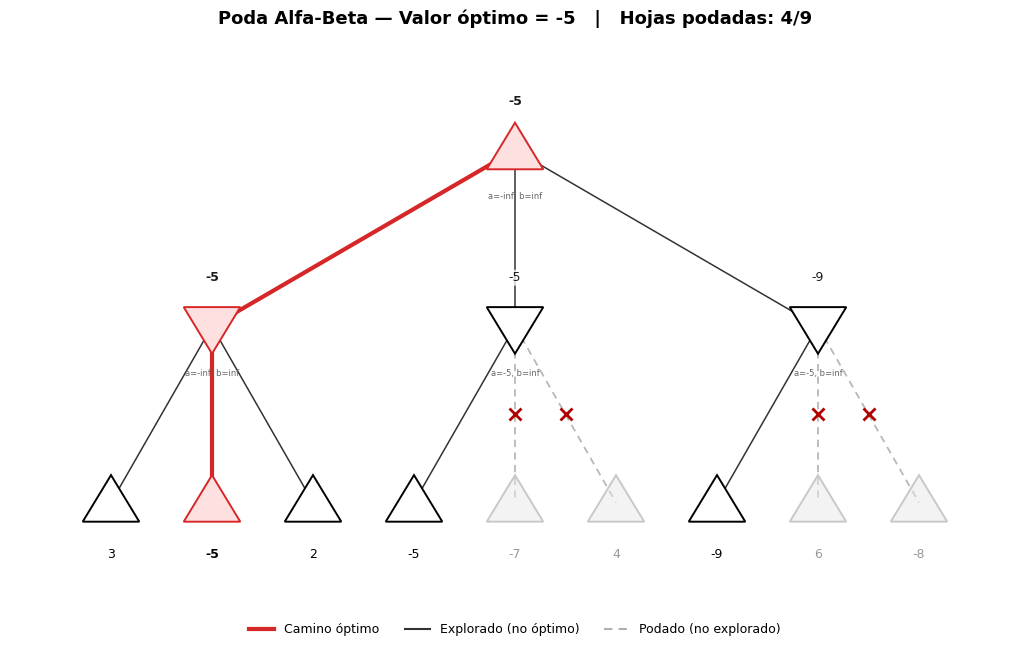

In [9]:
# 7.2 Visualización final
fig = draw_tree(
    root,
    title=f"Poda Alfa-Beta — Valor óptimo = {optimal_value}   |   Hojas podadas: {pruned_leaves}/{total_leaves}",
    show_alpha_beta=SHOW_ALPHA_BETA,
)
plt.show()

## 8. Ejemplo adicional (opcional)

La siguiente celda demuestra el algoritmo sobre un árbol aleatorio grande (5 niveles, 50 hojas) sin
modificar la configuración de la celda 2, simplemente llamando de nuevo a las funciones.

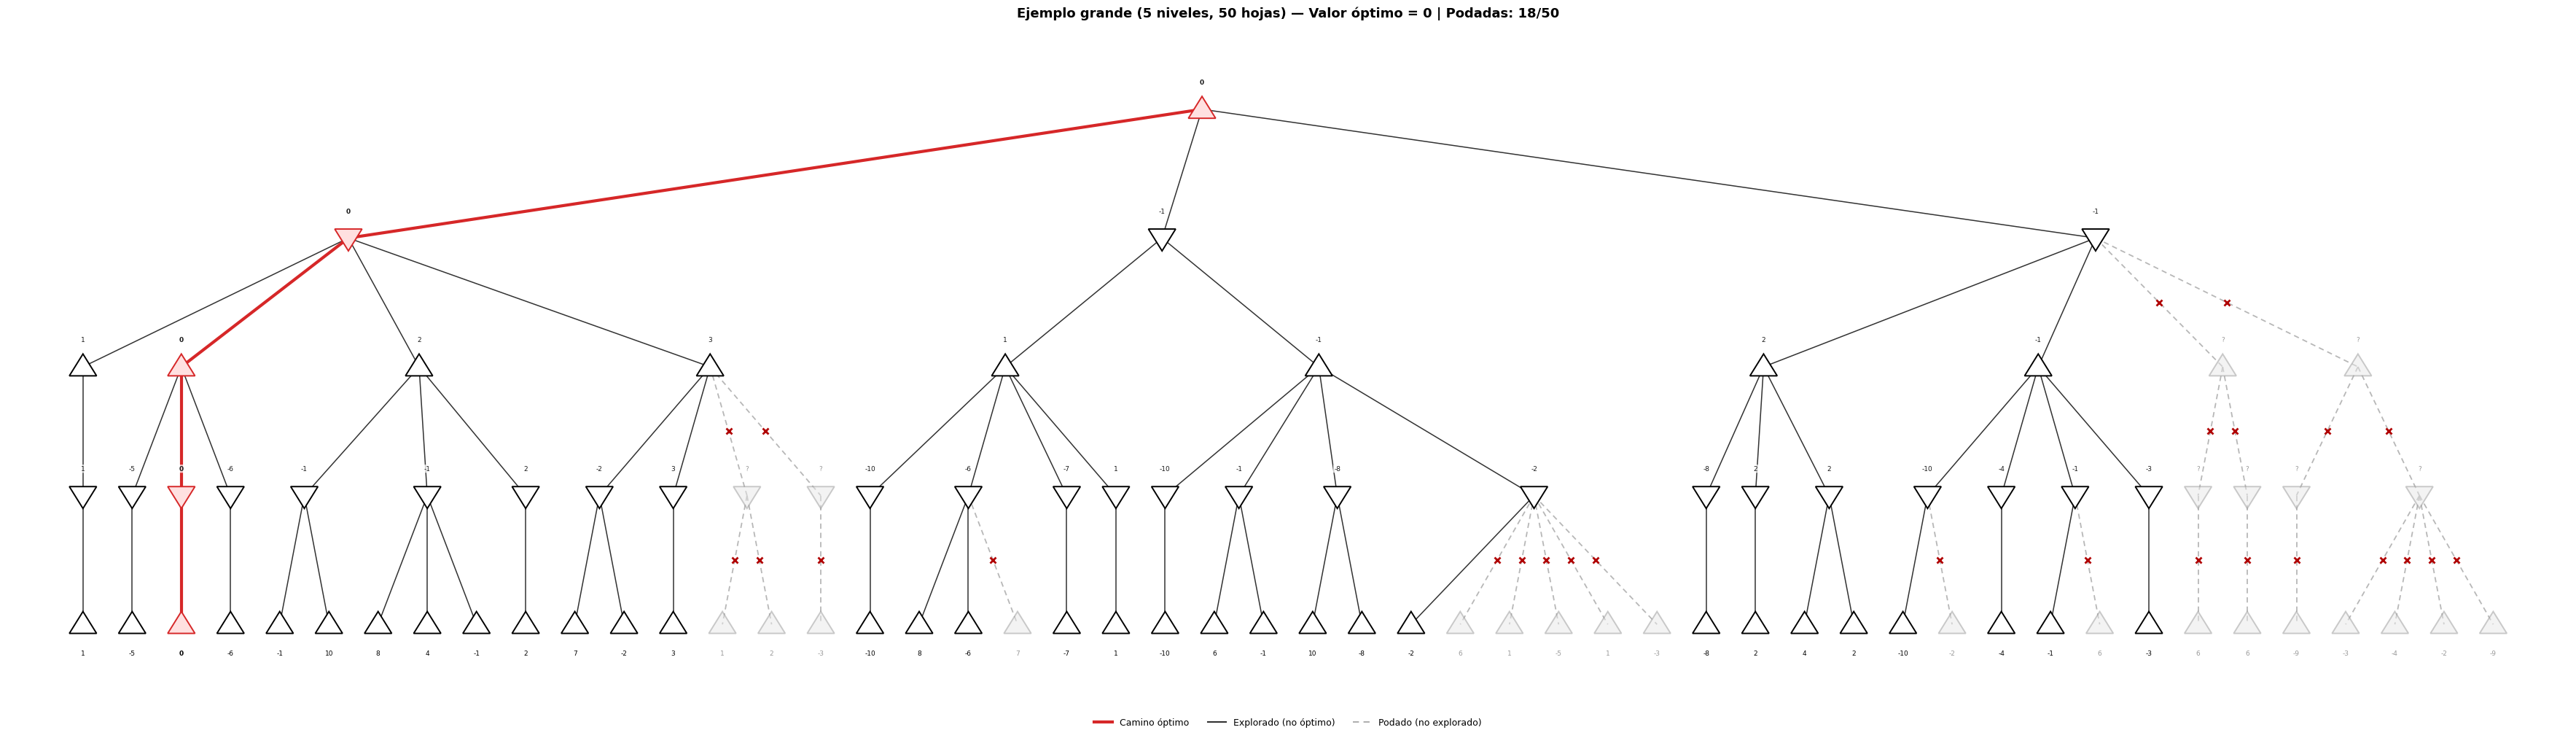

In [10]:
# 8. Demostración con el tamaño máximo permitido: 5 niveles, 50 hojas
demo_tree = generate_random_tree(num_levels=5, num_leaves=50, max_branch=4,
                                  val_range=(-10, 10), seed=7)
demo_root = build_tree(demo_tree)
demo_value = alphabeta(demo_root, -math.inf, math.inf)
mark_optimal_path(demo_root)
demo_pruned = count_pruned_leaves(demo_root)

fig2 = draw_tree(
    demo_root,
    title=f"Ejemplo grande (5 niveles, 50 hojas) — Valor óptimo = {demo_value} | Podadas: {demo_pruned}/50",
    show_alpha_beta=False,
)
plt.show()